In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/healthcare_data_for_task.csv")

In [3]:
print(df.head())

  Patient_ID  Age  Gender Blood_Type Medical_Condition Medical_Code  \
0      P0001   47    Male        AB+     Heart Disease       HEA004   
1      P0002   62  Female        AB-          Diabetes       DIA001   
2      P0003   36    Male        AB-     Heart Disease       HEA004   
3      P0004   51    Male         A+     Heart Disease       HEA004   
4      P0005   30    Male         A+          Diabetes       DIA001   

  Date_of_Admission Discharge_Date Admission_Type  Billing_Amount  
0        2025-05-10     2025-05-16      Emergency        23218.31  
1        2025-12-31     2026-01-02      Emergency        47010.56  
2        2025-11-10     2025-11-27      Emergency        39619.01  
3        2023-05-02     2023-05-07       Elective        35963.71  
4        2024-04-11     2024-04-17         Urgent        64615.93  


In [4]:
print(df.shape)

(1000, 10)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   object 
 3   Blood_Type         1000 non-null   object 
 4   Medical_Condition  1000 non-null   object 
 5   Medical_Code       970 non-null    object 
 6   Date_of_Admission  1000 non-null   object 
 7   Discharge_Date     1000 non-null   object 
 8   Admission_Type     1000 non-null   object 
 9   Billing_Amount     1000 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 78.3+ KB
None


In [6]:
print(df.describe())

               Age  Billing_Amount
count  1000.000000     1000.000000
mean     51.888000    77117.515720
std      19.256954    41955.242269
min      18.000000     5568.160000
25%      35.750000    40318.785000
50%      52.000000    77293.900000
75%      69.000000   113089.267500
max      85.000000   149921.800000


In [7]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition',
       'Medical_Code', 'Date_of_Admission', 'Discharge_Date', 'Admission_Type',
       'Billing_Amount'],
      dtype='object')


In [8]:
df['Age']
df['Patient_ID']

,Patient_ID
0,P0001
1,P0002
2,P0003
3,P0004
4,P0005
...,...
995,P0996
996,P0997
997,P0998
998,P0999


In [9]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Type,0
Medical_Condition,0
Medical_Code,30
Date_of_Admission,0
Discharge_Date,0
Admission_Type,0
Billing_Amount,0


In [10]:
df['Medical_Code']=df['Medical_Code'].fillna('Unknown')

In [11]:
df['Admission_Type']=(df['Admission_Type'].str.strip().str.title())

In [12]:
df['Admission_Type'].unique()

array(['Emergency', 'Elective', 'Urgent'], dtype=object)

In [13]:
df['Admission_Type'].value_counts()

,count
Admission_Type,
Emergency,381
Elective,368
Urgent,251


In [14]:
df['Date_of_Admission']=pd.to_datetime(df['Date_of_Admission'])
df['Discharge_Date']=pd.to_datetime(df['Discharge_Date'])

In [15]:
df['Date_of_Admission'].dt.year

,Date_of_Admission
0,2025
1,2025
2,2025
3,2023
4,2024
...,...
995,2023
996,2025
997,2023
998,2023


In [16]:
df['Date_of_Admission'].dt.month

,Date_of_Admission
0,5
1,12
2,11
3,5
4,4
...,...
995,3
996,4
997,5
998,2


In [17]:
df['Date_of_Admission'].dt.day

,Date_of_Admission
0,10
1,31
2,10
3,2
4,11
...,...
995,16
996,17
997,8
998,11


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         1000 non-null   object        
 1   Age                1000 non-null   int64         
 2   Gender             1000 non-null   object        
 3   Blood_Type         1000 non-null   object        
 4   Medical_Condition  1000 non-null   object        
 5   Medical_Code       1000 non-null   object        
 6   Date_of_Admission  1000 non-null   datetime64[ns]
 7   Discharge_Date     1000 non-null   datetime64[ns]
 8   Admission_Type     1000 non-null   object        
 9   Billing_Amount     1000 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(6)
memory usage: 78.3+ KB
None


In [20]:
df['Stay _Days']=(df['Discharge_Date']-df['Date_of_Admission']).dt.days

In [21]:
df['Billing_Amount'].describe()

,Billing_Amount
count,1000.000000
mean,77117.515720
std,41955.242269
min,5568.160000
25%,40318.785000
50%,77293.900000
75%,113089.267500
max,149921.800000


In [25]:
df.groupby('Medical_Condition')['Age'].mean()

,Age
Medical_Condition,
Arthritis,52.674641
Asthma,49.919598
Diabetes,53.130653
Heart Disease,52.180995
Hypertension,51.395349


In [26]:
pd.crosstab(df['Medical_Condition'],df['Gender'])

Gender,Female,Male
Medical_Condition,,
Arthritis,95,114
Asthma,101,98
Diabetes,110,89
Heart Disease,104,117
Hypertension,80,92


Text(0.5, 1.0, 'Admission Type')

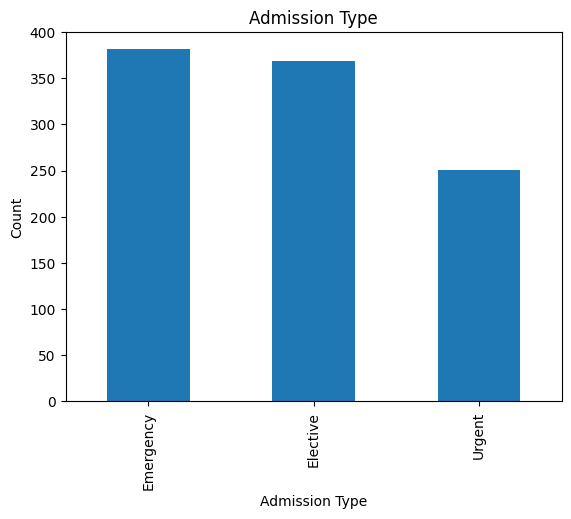

In [27]:
df['Admission_Type'].value_counts().plot(kind='bar')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.title('Admission Type')